<a href="https://colab.research.google.com/github/ibrahimbugrasan/HasarliAracTespiti-2/blob/main/DeitModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Some weights of DeiTForImageClassification were not initialized from the model checkpoint at facebook/deit-base-distilled-patch16-224 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model eğitimine başlıyor...


<ipython-input-2-a5d2b4373921>:124: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  all_outputs_softmax = torch.softmax(torch.tensor(all_outputs), dim=1).numpy()


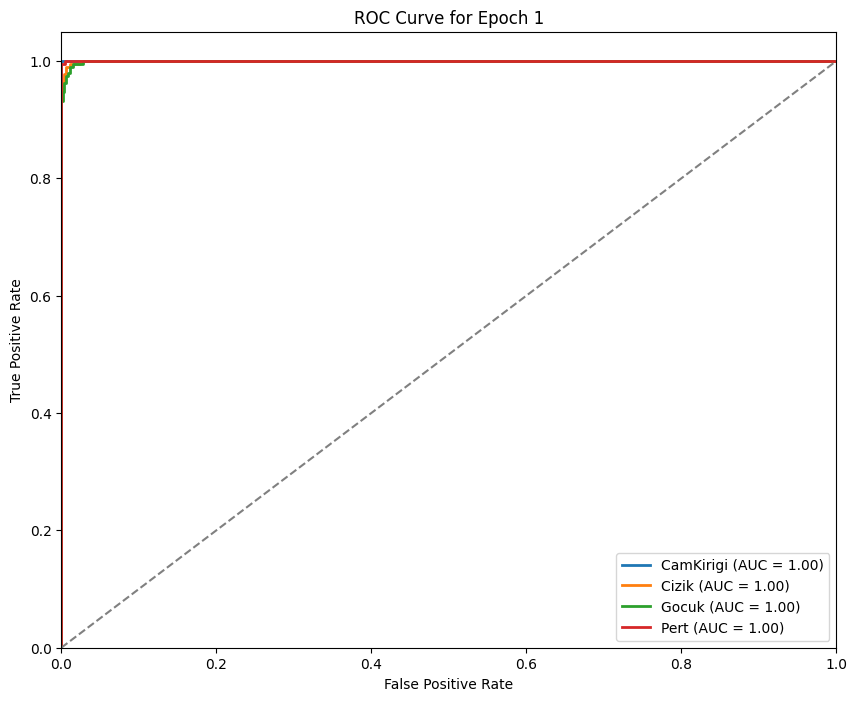

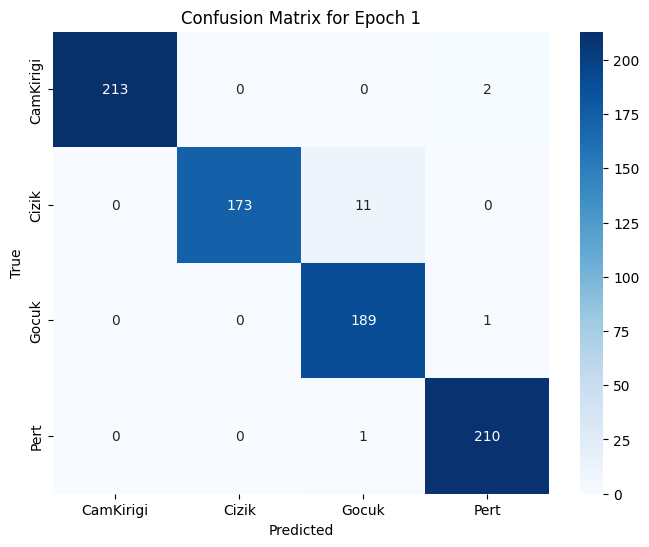

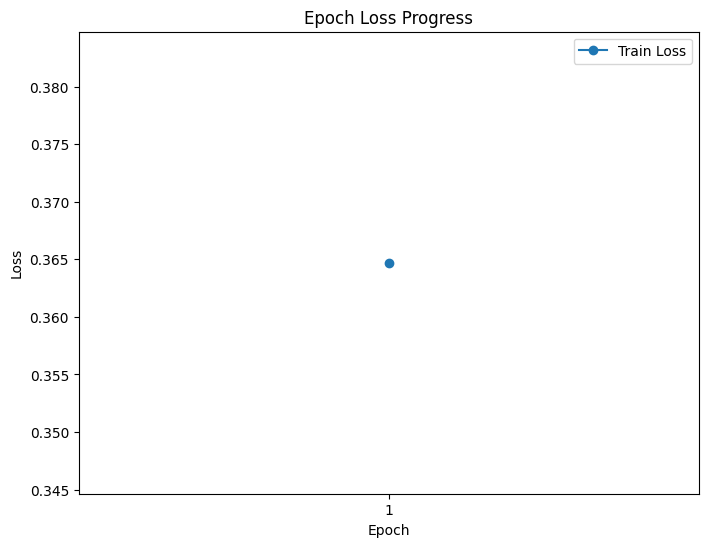

Epoch 1/10
Train Loss: 0.3647


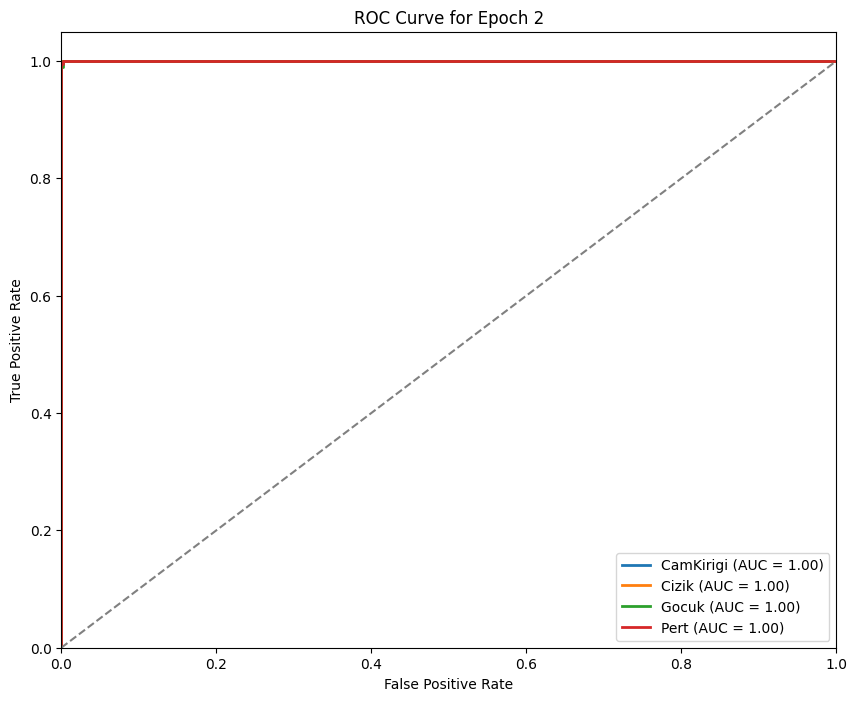

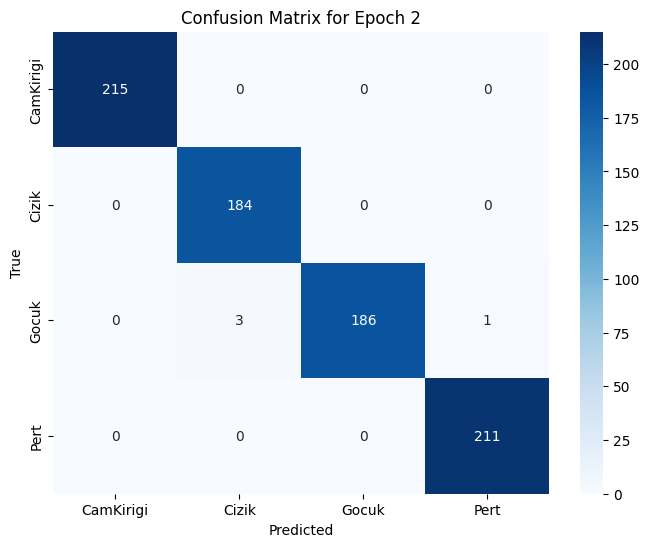

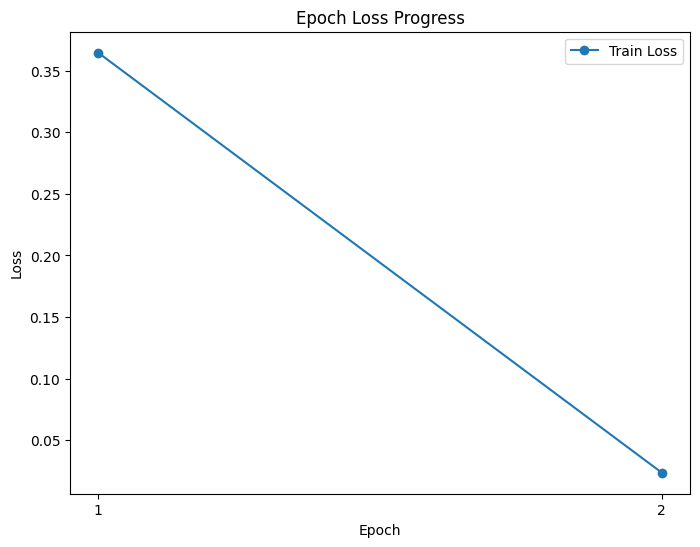

Epoch 2/10
Train Loss: 0.0235


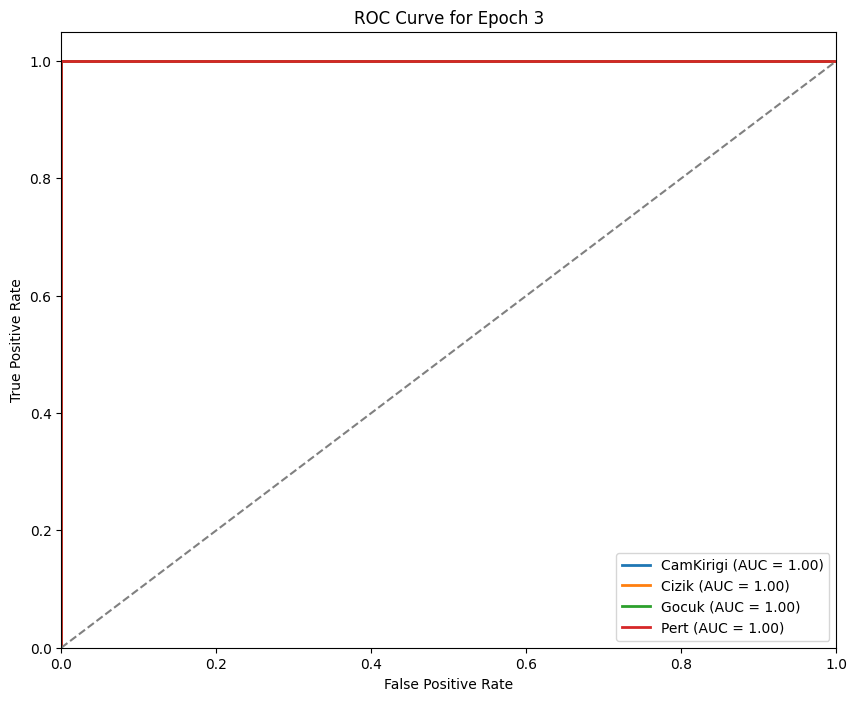

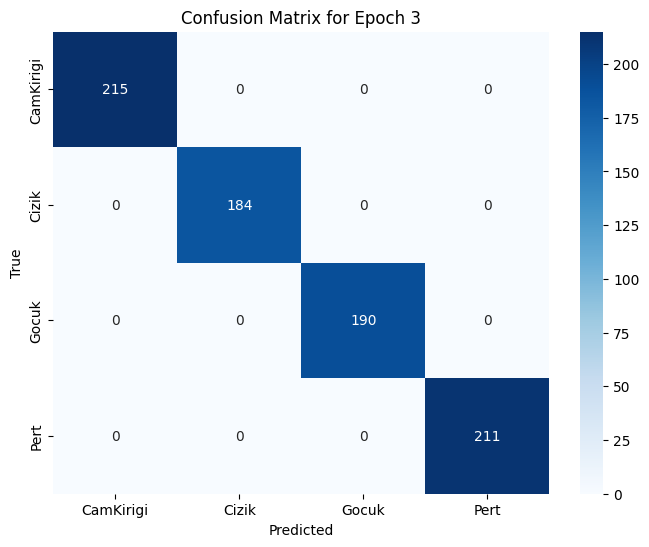

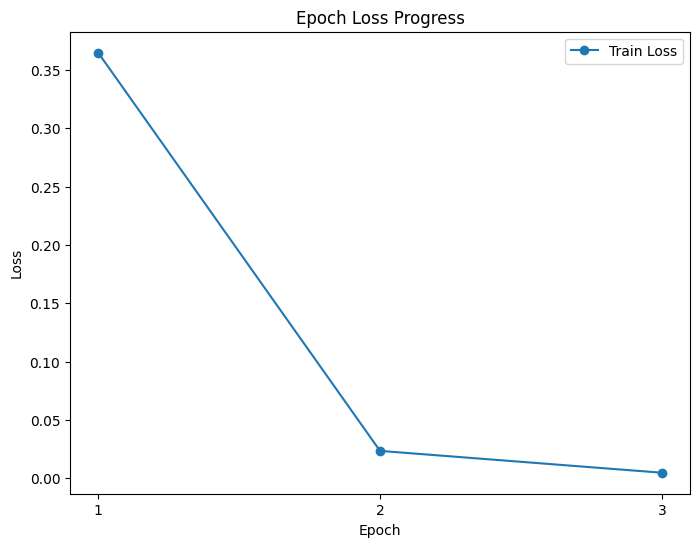

Epoch 3/10
Train Loss: 0.0048


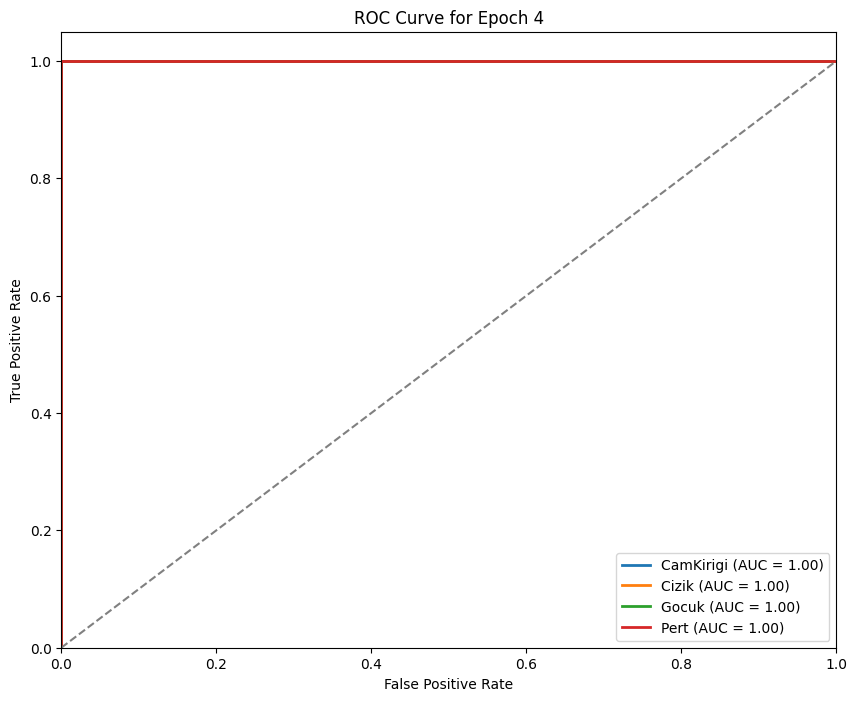

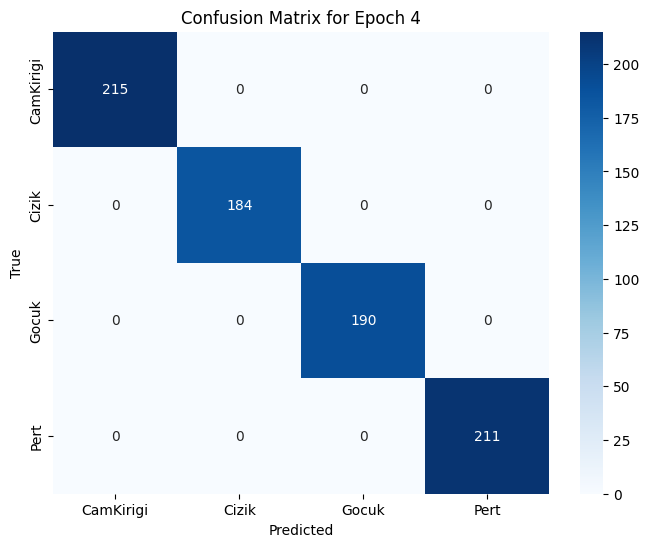

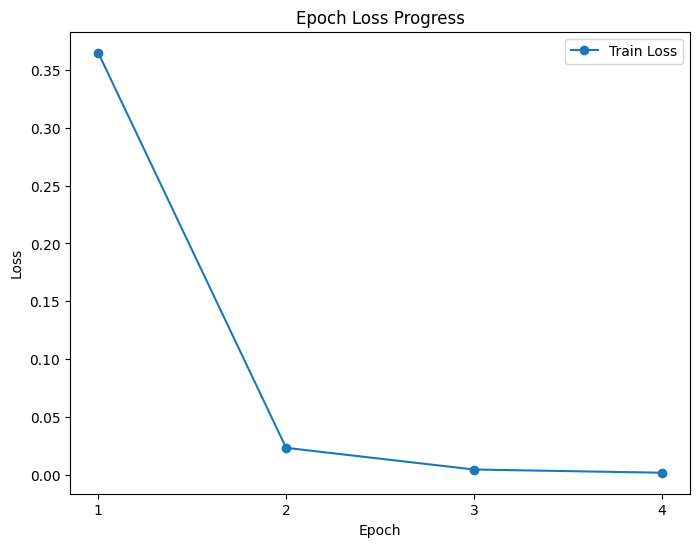

Epoch 4/10
Train Loss: 0.0021


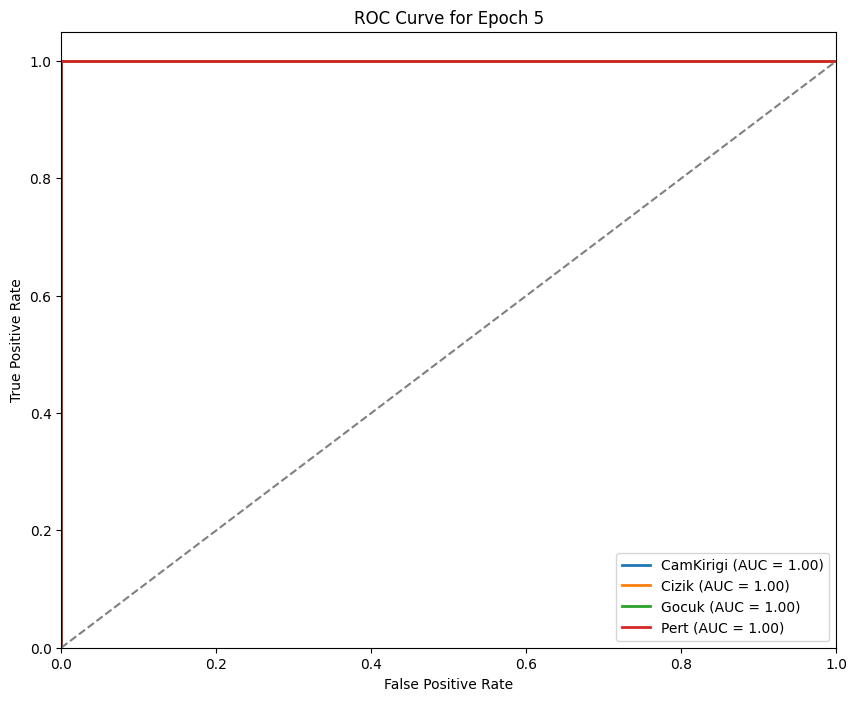

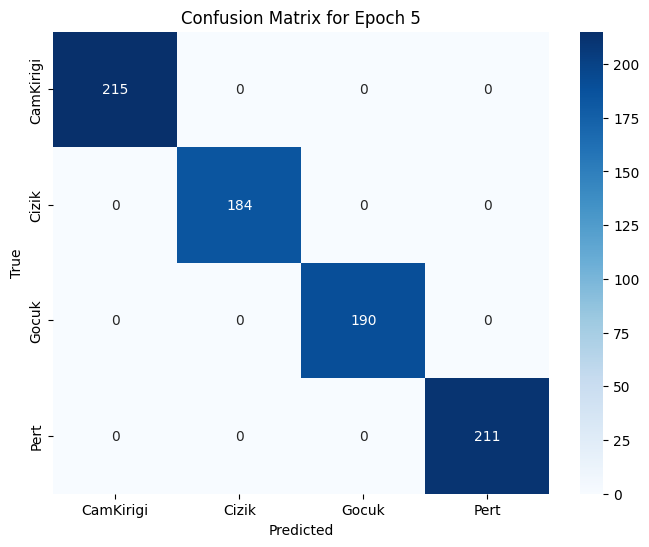

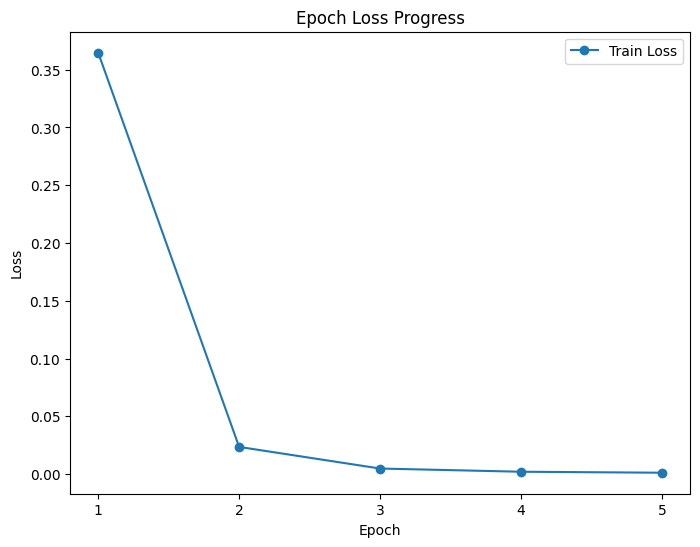

Epoch 5/10
Train Loss: 0.0012


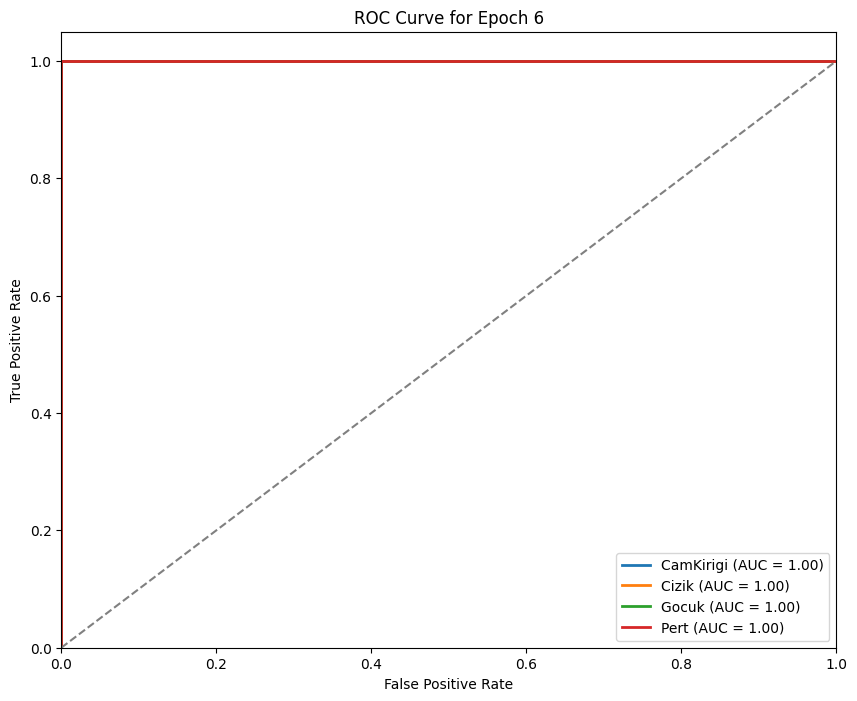

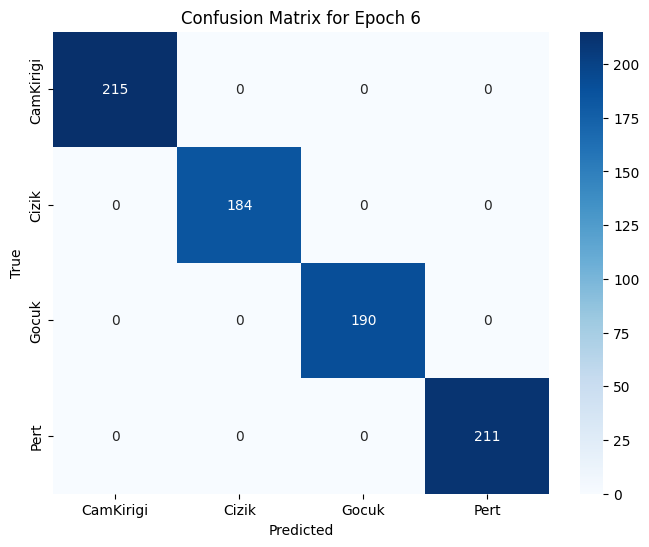

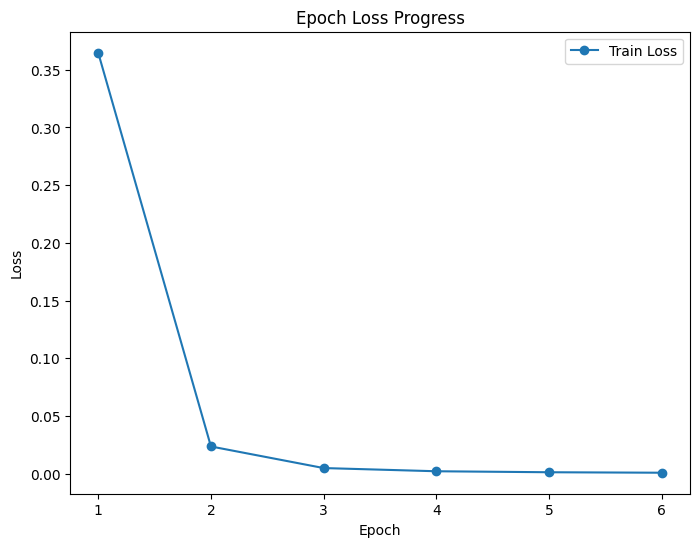

Epoch 6/10
Train Loss: 0.0008


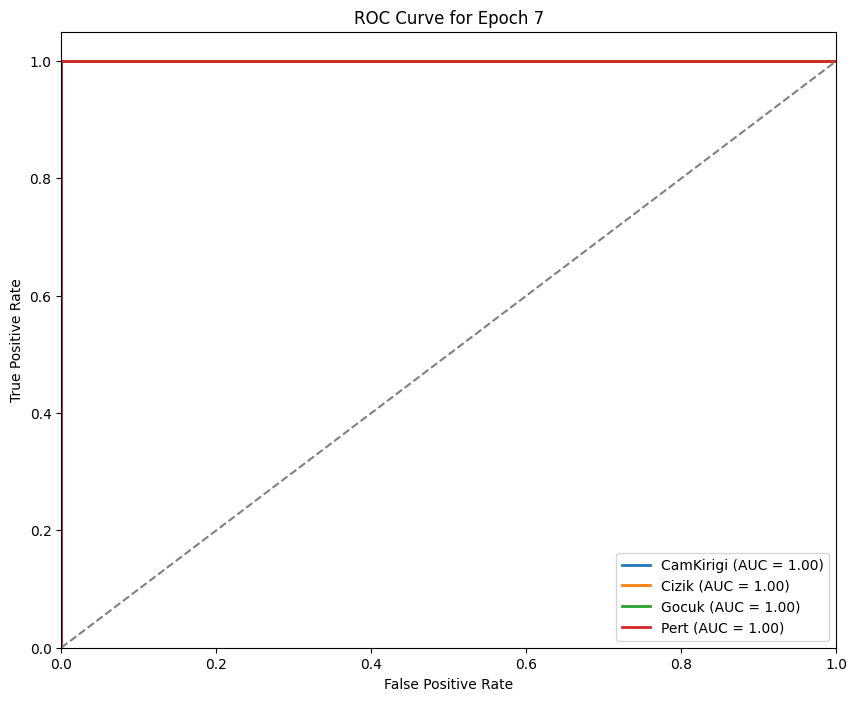

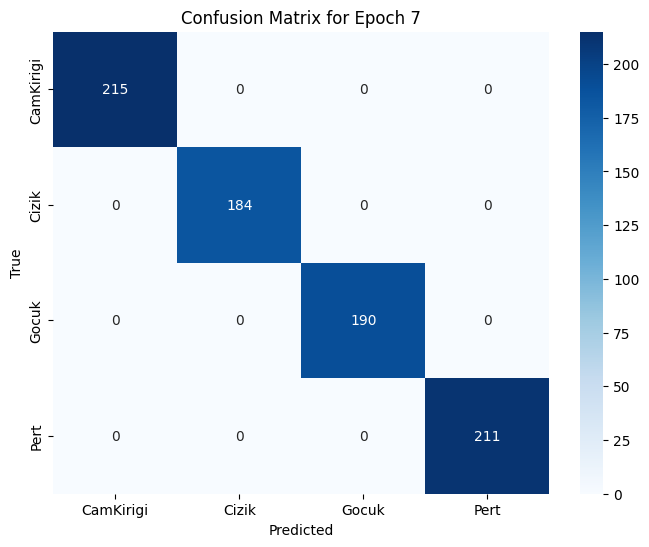

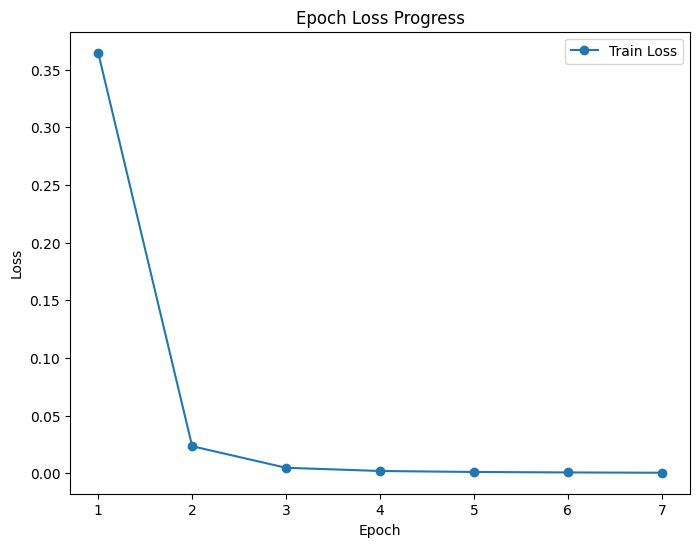

Epoch 7/10
Train Loss: 0.0006


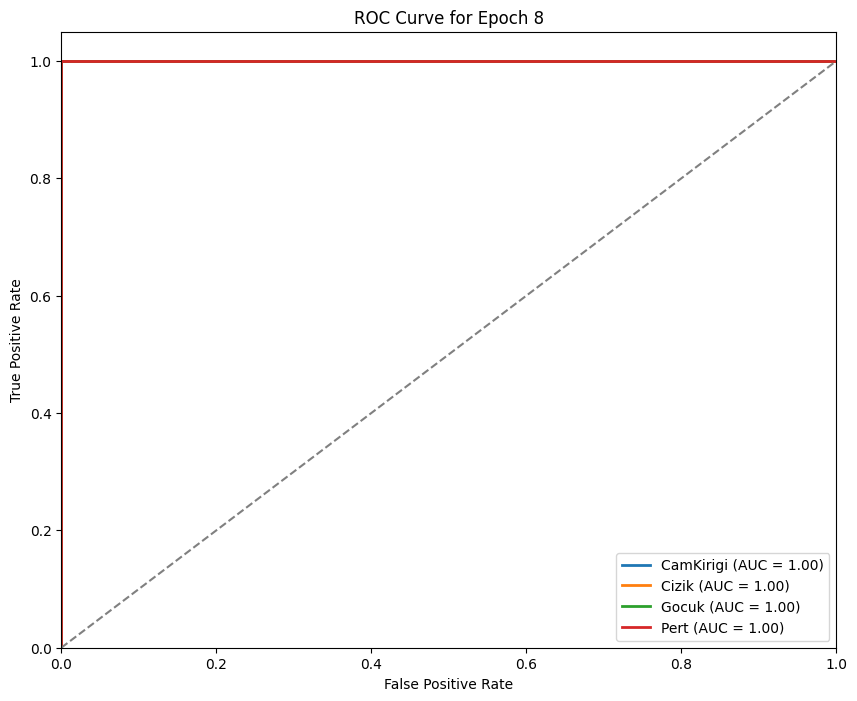

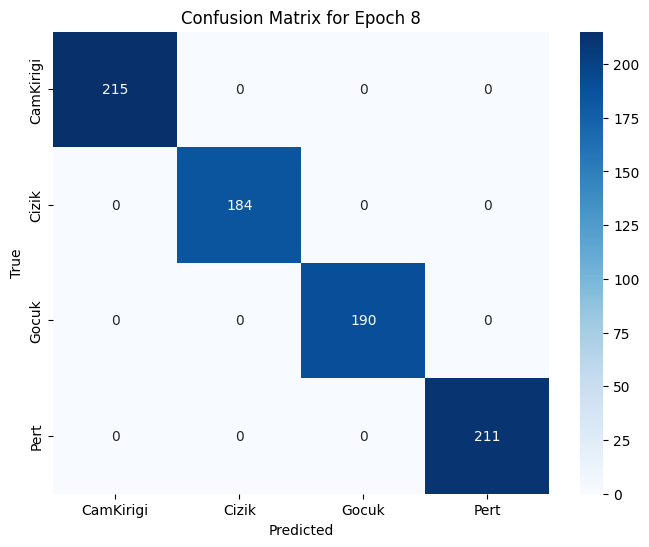

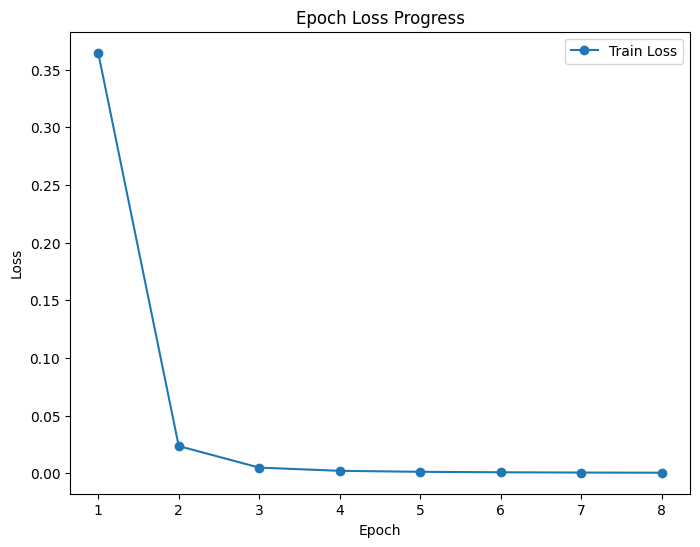

Epoch 8/10
Train Loss: 0.0004


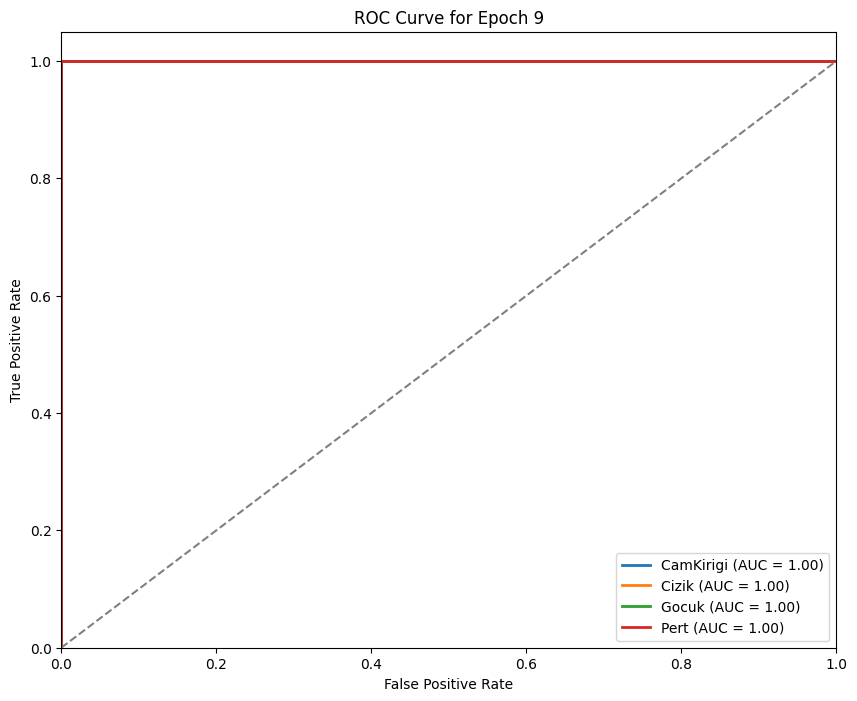

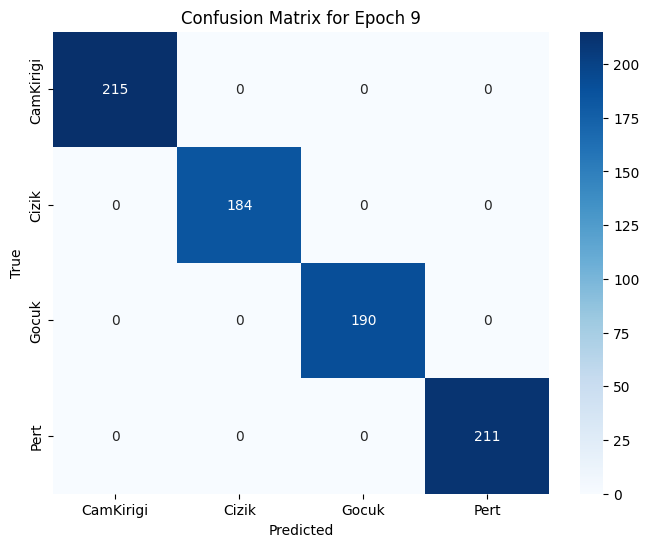

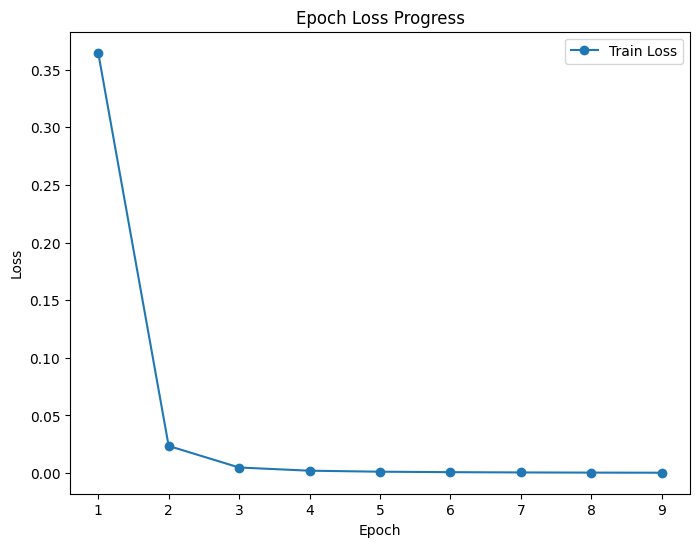

Epoch 9/10
Train Loss: 0.0003


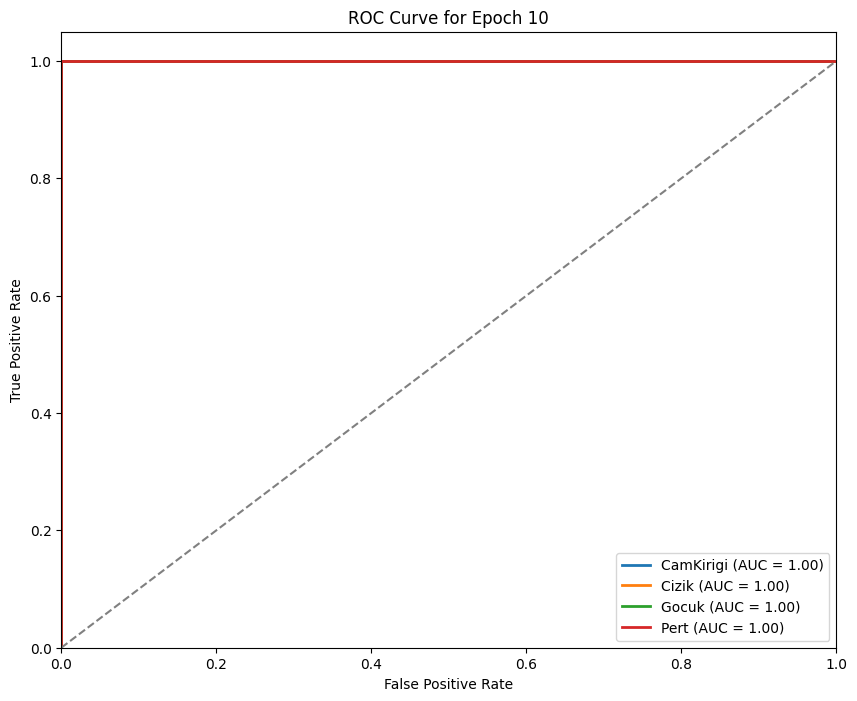

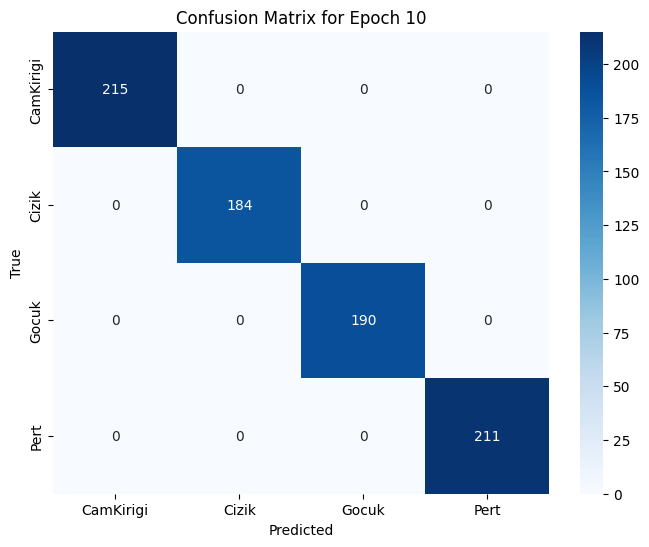

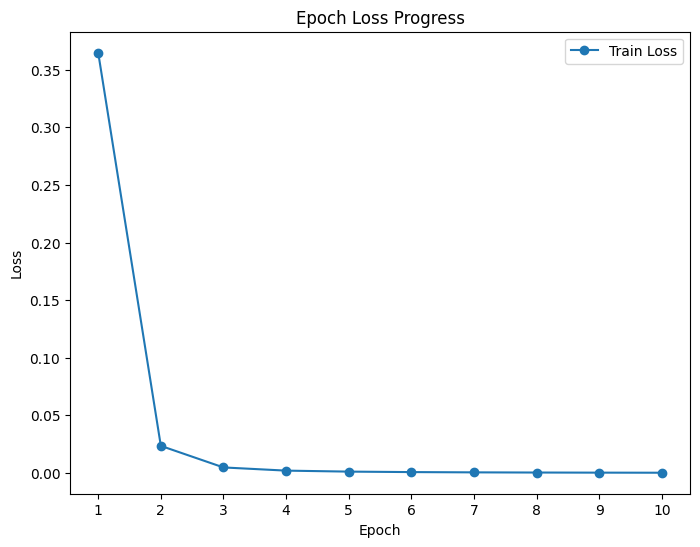

Epoch 10/10
Train Loss: 0.0002


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from transformers import DeiTForImageClassification
from google.colab import drive

# DeiT Base Distilled modeli yükleyelim
model_name = 'facebook/deit-base-distilled-patch16-224'
model = DeiTForImageClassification.from_pretrained(model_name, num_labels=4, ignore_mismatched_sizes=True)
model.classifier = torch.nn.Linear(model.classifier.in_features, 4)

# Veri yükleme kısmı (Google Drive üzerinde verinizi yükleyin)
drive.mount('/content/drive')

# Veriyi burada uygun şekilde yükleyin (örneğin, 'all_data' klasörü altında)
full_data = torchvision.datasets.ImageFolder('/content/drive/MyDrive/YazLabProjesi/DATABASE', transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]))

# Eğitim ve test verisi ayırma işlemi
train_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_size
train_data, test_data = torch.utils.data.random_split(full_data, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=False)

# Eğitim Ayarları
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# 1. Yardımcı Fonksiyonlar
def plot_roc_curve(y_true, y_score, class_names, epoch):
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        auc_value = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {auc_value:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Epoch {epoch+1}')
    plt.legend(loc='lower right')
    plt.show()

def plot_confusion_matrix(cm, class_names, epoch):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix for Epoch {epoch+1}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_loss(train_losses, epoch):
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
    plt.title('Epoch Loss Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(range(1, len(train_losses) + 1))
    plt.legend()
    plt.show()

# 2. Performans Metrik Hesaplama
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    # Sensitivity (Duyarlılık) ve Specificity (Özgüllük) hesaplama
    sensitivity = recall_score(y_true, y_pred, average=None)  # her sınıf için duyarlılık
    specificity = []
    for i in range(len(cm)):
        tn = cm[i].sum() - cm[i][i]  # True Negative
        fp = cm[:, i].sum() - cm[i][i]  # False Positive
        specificity.append(tn / (tn + fp) if tn + fp != 0 else 0)

    # AUC hesaplama
    lb = LabelBinarizer()
    y_true_bin = lb.fit_transform(y_true)
    auc_value = roc_auc_score(y_true_bin, y_pred, multi_class='ovr')

    return accuracy, recall, precision, f1, sensitivity, specificity, auc_value, cm

# 3. Eğitim Fonksiyonu
def train_model(model, train_loader, test_loader, epochs=10):
    train_losses = []
    class_names = full_data.classes  # Sınıf isimlerini buradan alıyoruz

    print("Model eğitimine başlıyor...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        # Eğitim
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # Test (Doğrulama)
        model.eval()
        all_preds = []
        all_labels = []
        all_outputs = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).logits
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())

        # One-hot encoding için LabelBinarizer kullanarak all_labels'ı dönüştür
        lb = LabelBinarizer()
        all_labels_one_hot = lb.fit_transform(all_labels)

        # Softmax ile olasılıkları elde et
        all_outputs_softmax = torch.softmax(torch.tensor(all_outputs), dim=1).numpy()

        # Performans metriklerini hesapla
        accuracy, recall, precision, f1, sensitivity, specificity, auc_value, cm = calculate_metrics(all_labels, all_preds)

        # Grafikleri çiz
        plot_roc_curve(all_labels_one_hot, all_outputs_softmax, class_names, epoch)
        plot_confusion_matrix(cm, class_names, epoch)
        plot_loss(train_losses, epoch)

        # Metrikleri yazdır
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f}")
        print(f"Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1-Score: {f1:.4f}")
        print(f"Sensitivity: {sensitivity}, Specificity: {specificity}")
        print(f"AUC: {auc_value:.4f}")

# 4. Modeli Eğitme
train_model(model, train_loader, test_loader, epochs=10)

In [ ]:
!pip install pytorch